# Medical Insurance Data Preparation and Dimensionality Reduction

## Introduction
[Write this section in your own words.]

## Dataset Characterisation
[Write this section in your own words.]

## Data Preparation and EDA Rationale
[Write this section in your own words.]

BMI outliers were retained rather than removed or capped. Values above 35-50 are clinically
valid indicators of severe/morbid obesity, not data entry errors, and they correlate strongly
(non-linearly) with insurance charges, especially combined with smoker status. Deleting or
winsorising these values would discard genuine risk signal the model needs to price high-cost
claims correctly. The BMI distribution is right-skewed with values extending to ~53.13, which
reflects true clinical observations rather than a data quality issue.

## Encoding, Scaling and Feature Engineering Rationale
[Write this section in your own words.]

Raw BMI is kept unmodified for models that handle extreme values naturally (e.g. tree-based
models). For PCA/LDA, `StandardScaler` is applied so that large BMI values do not dominate the
principal components purely because of scale (an alternative, `RobustScaler`, uses median/IQR
and is even more resilient to extreme values, but was not required here since scaling rather than
outlier removal already addresses the variance issue). Separately, `bmi_category` bins raw BMI
into clinical risk thresholds (underweight/healthy/overweight/obese) via `pd.cut`, capturing the
non-linear jump in charges once BMI crosses 30, without altering or discarding the underlying
continuous BMI values.

## PCA and LDA Comparison
[Write this section in your own words.]

## Findings and Conclusions
[Write this section in your own words.]

## References
[Add Harvard-style references and citations used in your report.]

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

In [2]:
df = pd.read_excel("insurance_data.xlsx")

In [3]:
df.head(100)

,age,gender,bmi,children,smoker,region,NoClaimsBonus,charges
0,19,female,27.900,0.0,yes,southwest,0.05,16884.92400
1,18,male,33.770,1.0,no,southeast,0.20,1725.55230
2,28,male,33.000,3.0,no,southeast,0.10,4449.46200
3,33,male,22.705,0.0,no,northwest,0.05,21984.47061
4,32,male,28.880,0.0,no,northwest,0.20,3866.85520
...,...,...,...,...,...,...,...,...
95,28,female,37.620,1.0,no,southeast,0.05,3766.88380
96,54,female,30.800,3.0,no,southwest,0.15,12105.32000
97,55,male,38.280,0.0,no,southeast,0.20,10226.28420
98,56,male,19.950,0.0,yes,northeast,0.10,22412.64850


In [4]:
# Dataset Shape, Duplicate Check
print(f"Shape: {df.shape}")
print(f"Duplicates: {df.duplicated().sum()}")

# Missing Value Counts and  Data Types
print("\n--- Missing Values & Types ---")
missing_info = pd.DataFrame({
    'Dtype': df.dtypes,
    'Missing_Count': df.isnull().sum(),
    'Missing_Pct': (df.isnull().sum() / len(df)) * 100
})
print(missing_info)

# Range Audit & Suspicious Values (Children > 5)
print("\n Children Column Range Check (> 5) ")
suspicious_children = df[df['children'] > 5]

print(f"\n Total rows with children > 5: {len(suspicious_children)}")
print(suspicious_children[['age', 'gender', 'children', 'smoker', 'charges']])

Shape: (1338, 8)
Duplicates: 0

--- Missing Values & Types ---
                 Dtype  Missing_Count  Missing_Pct
age              int64              0     0.000000
gender             str              5     0.373692
bmi            float64              5     0.373692
children       float64              5     0.373692
smoker             str              0     0.000000
region             str              0     0.000000
NoClaimsBonus  float64              0     0.000000
charges        float64              7     0.523169

 Children Column Range Check (> 5) 

 Total rows with children > 5: 3
     age  gender  children smoker     charges
102   18  female      10.0     no  21344.8467
212   24    male      12.0     no   3537.7030
294   25    male      13.0     no   3906.1270


In [5]:
df.describe()

,age,bmi,children,NoClaimsBonus,charges
count,1338.000000,1333.000000,1333.000000,1338.000000,1331.000000
mean,39.207025,30.685728,1.115529,0.124439,13241.270533
std,14.049960,6.090499,1.303209,0.055953,12102.504296
min,18.000000,15.960000,0.000000,0.050000,1121.873900
25%,27.000000,26.315000,0.000000,0.050000,4729.002375
50%,39.000000,30.400000,1.000000,0.100000,9361.326800
75%,51.000000,34.700000,2.000000,0.150000,16582.138605
max,64.000000,53.130000,13.000000,0.200000,63770.428010


In [6]:
# Create a cleaned dataset used by all later analysis.
df_clean = df.copy()

# Standardise text values while preserving missing values.
for col in ["gender", "smoker", "region"]:
    df_clean[col] = df_clean[col].astype("string").str.strip().str.lower()

# Correct the known region spelling issue before imputation.
df_clean["region"] = df_clean["region"].replace({"northteast": "northeast"})

# Values above five contradict the supplied definition of children/dependants.
invalid_children = df_clean["children"].isna() | (df_clean["children"] > 5)
print(f"Problematic children values: {invalid_children.sum()}")
df_clean.loc[df_clean["children"] > 5, "children"] = 5

# Median is robust to skewed numeric features; mode preserves categorical values.
for col in ["age", "bmi", "children", "charges"]:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# smoker must be imputed too, otherwise smoker_binary carries NaNs into modelling.
for col in ["gender", "smoker", "region"]:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Binary target used only to compare smoker and non-smoker class separation.
df_clean["smoker_binary"] = df_clean["smoker"].map({"yes": 1, "no": 0})

# BMI categories provide an interpretable non-linear risk feature.
df_clean["bmi_category"] = pd.cut(
    df_clean["bmi"],
    bins=[0, 18.5, 25, 30, np.inf],
    labels=["underweight", "healthy", "overweight", "obese"],
    right=False
)

# Checked after all derived columns exist so smoker_binary/bmi_category nulls aren't missed.
print(f"Missing values after cleaning: {df_clean.isna().sum().sum()}")
print(f"Children values above 5 after cleaning: {(df_clean['children'] > 5).sum()}")
if df_clean.isna().sum().sum() > 0:
    print("\n--- Remaining Nulls by Column ---")
    print(df_clean.isna().sum()[df_clean.isna().sum() > 0])

Problematic children values: 8
Missing values after cleaning: 0
Children values above 5 after cleaning: 0


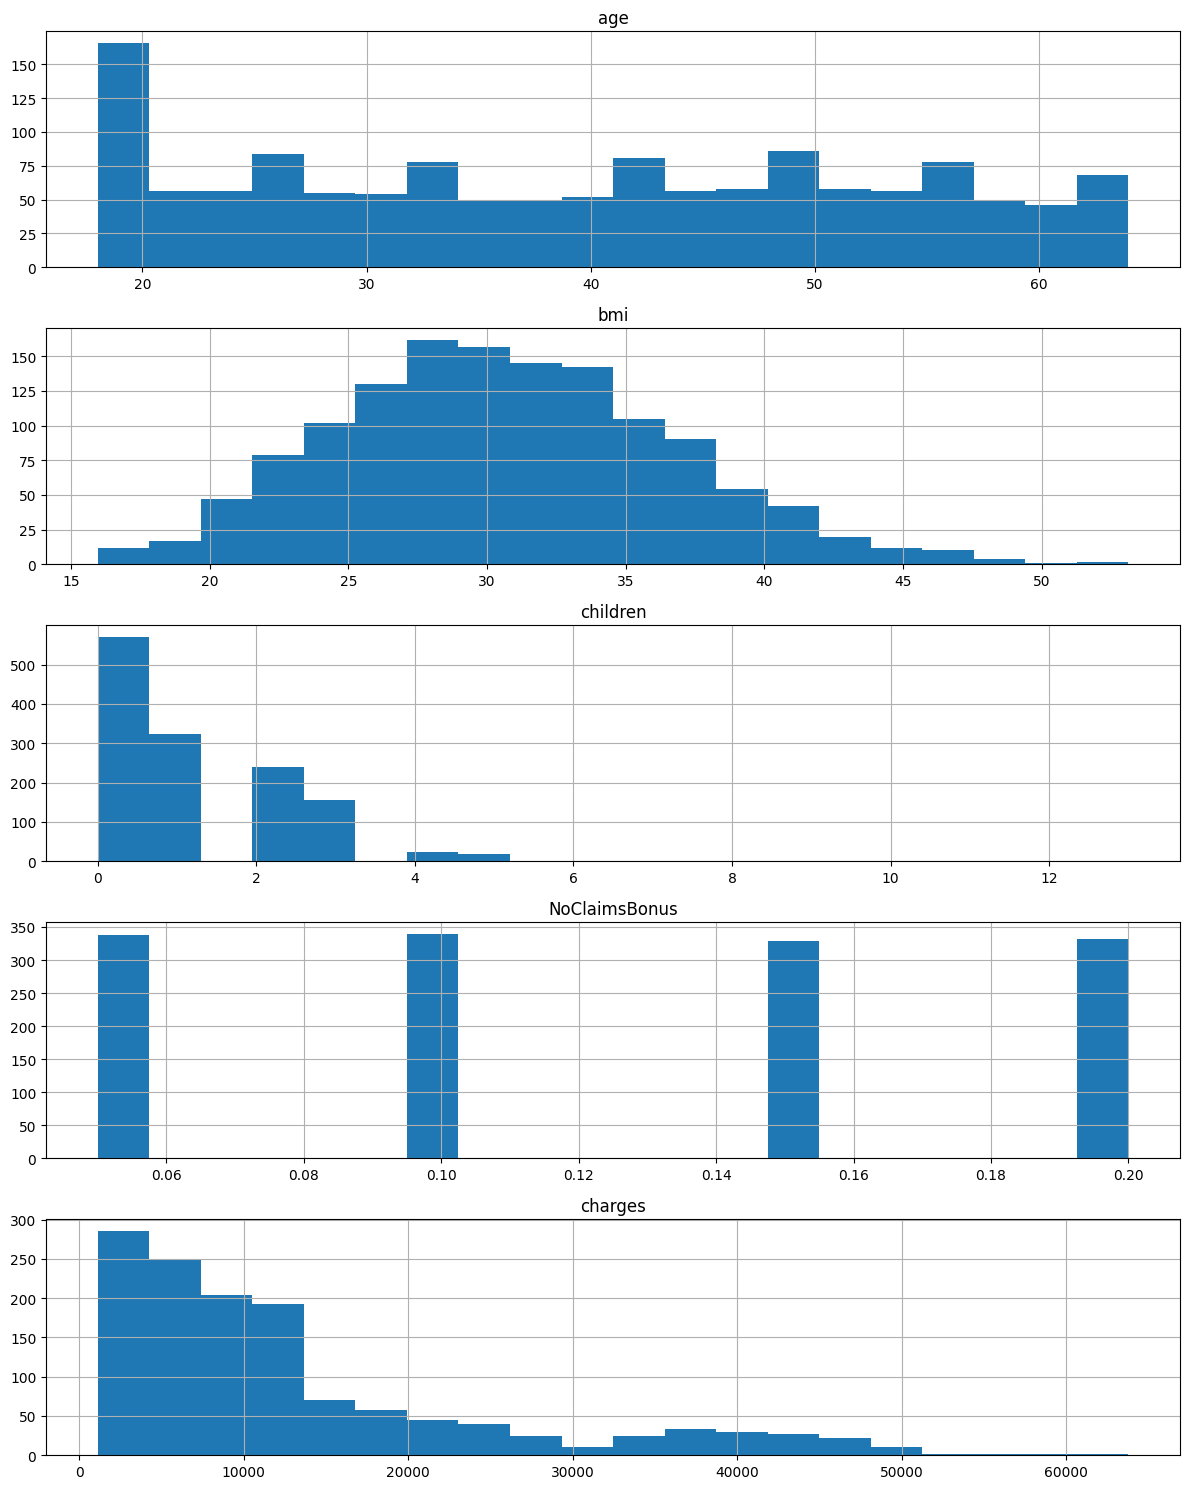

In [7]:
numeric_df = df.select_dtypes(include=np.number)
fig, axes = plt.subplots(len(numeric_df.columns), 1, figsize=(12, 3 * len(numeric_df.columns)))

numeric_df.hist(bins=20, ax=axes)
plt.tight_layout()
plt.show()

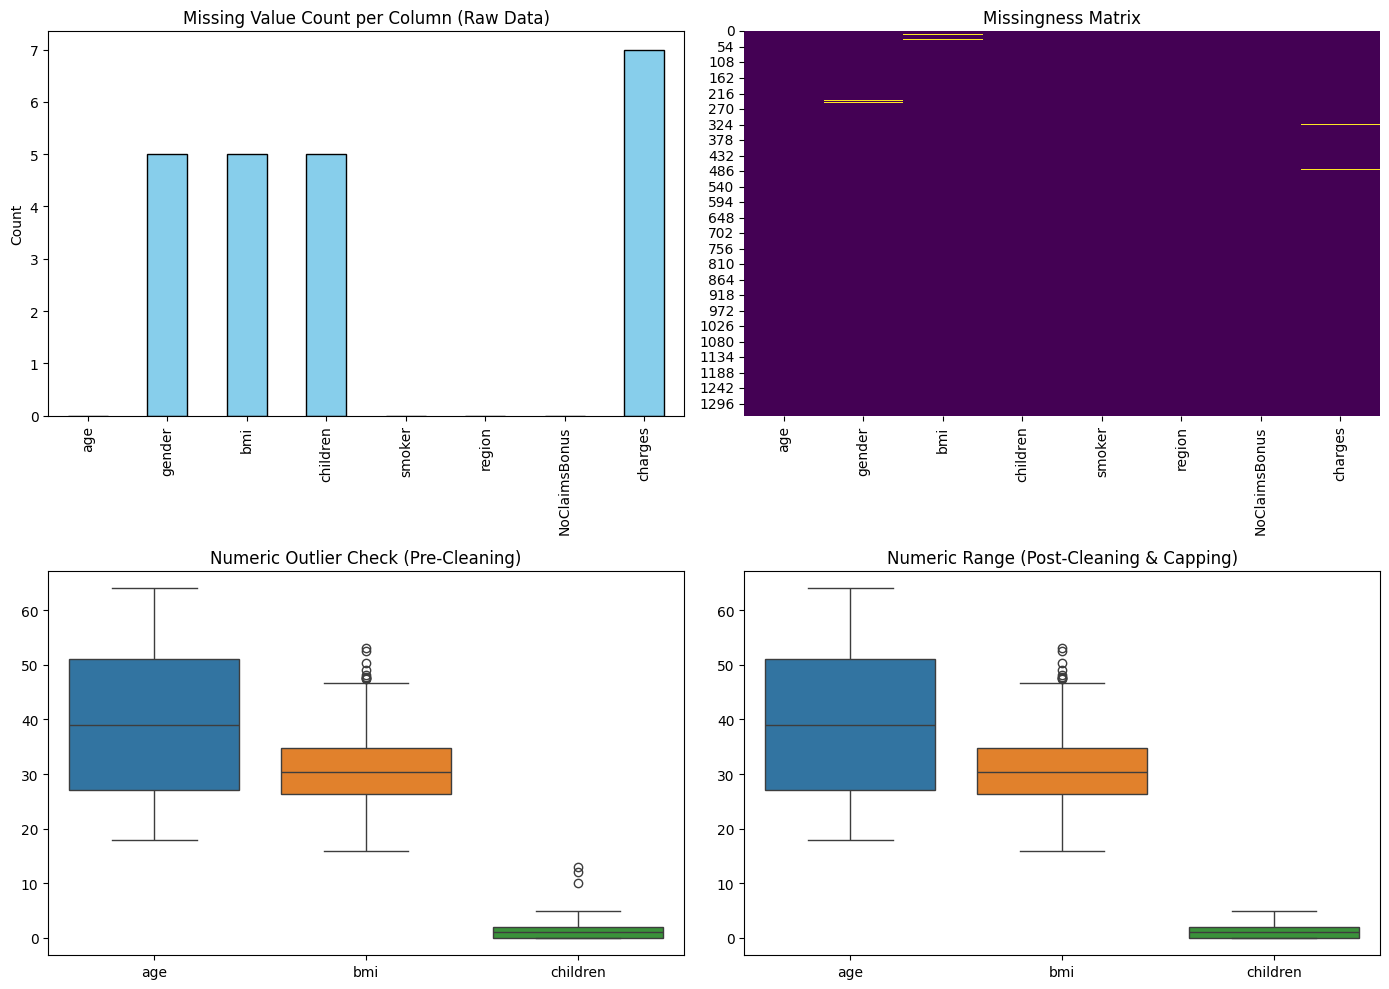

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#  Missing Value Counts
df.isnull().sum().plot(kind='bar', ax=axes[0, 0], color='skyblue', edgecolor='black')
axes[0, 0].set_title('Missing Value Count per Column (Raw Data)')
axes[0, 0].set_ylabel('Count')

# Missingness Heatmap
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', ax=axes[0, 1])
axes[0, 1].set_title('Missingness Matrix')

# Pre-Cleaning Boxplots
sns.boxplot(data=df[['age', 'bmi', 'children']], ax=axes[1, 0])
axes[1, 0].set_title('Numeric Outlier Check (Pre-Cleaning)')

# Post-Cleaning Boxplots
sns.boxplot(data=df_clean[['age', 'bmi', 'children']], ax=axes[1, 1])
axes[1, 1].set_title('Numeric Range (Post-Cleaning & Capping)')

plt.tight_layout()
plt.show()

In [9]:
from sklearn.metrics import silhouette_score

# Use only cleaned features. NoClaimsBonus remains numeric because its ordered percentage values
# represent increasing discount levels; categorical variables are one-hot encoded.
feature_cols_smoker = [
    "age", "gender", "bmi", "bmi_category", "children", "region", "NoClaimsBonus"
 ]
categorical_features = ["gender", "bmi_category", "region"]

X_smoker_raw = df_clean[feature_cols_smoker]
X_smoker_encoded = pd.get_dummies(
    X_smoker_raw, columns=categorical_features, drop_first=True, dtype=int
 )
y_smoker = df_clean["smoker_binary"]

scaler = StandardScaler()
X_smoker_scaled = scaler.fit_transform(X_smoker_encoded)

# Main comparison excludes charges to avoid using an outcome feature.
pca_no_charges = PCA(n_components=2)
X_pca_no = pca_no_charges.fit_transform(X_smoker_scaled)
lda_no_charges = LDA(n_components=1)
X_lda_no = lda_no_charges.fit_transform(X_smoker_scaled, y_smoker)

# Sensitivity analysis tests the effect of including medical charges.
feature_cols_with_charges = feature_cols_smoker + ["charges"]
X_charges_raw = df_clean[feature_cols_with_charges]
X_charges_encoded = pd.get_dummies(
    X_charges_raw, columns=categorical_features, drop_first=True, dtype=int
 )
X_charges_scaled = scaler.fit_transform(X_charges_encoded)
pca_with_charges = PCA(n_components=2)
X_pca_with = pca_with_charges.fit_transform(X_charges_scaled)
lda_with_charges = LDA(n_components=1)
X_lda_with = lda_with_charges.fit_transform(X_charges_scaled, y_smoker)

# A higher silhouette score indicates more distinct smoker/non-smoker groups in the projection.
print(f"PCA variance explained (without charges): {pca_no_charges.explained_variance_ratio_.sum():.3f}")
print(f"PCA variance explained (with charges): {pca_with_charges.explained_variance_ratio_.sum():.3f}")
print(f"PCA silhouette score (without charges): {silhouette_score(X_pca_no, y_smoker):.3f}")
print(f"LDA silhouette score (without charges): {silhouette_score(X_lda_no, y_smoker):.3f}")

PCA variance explained (without charges): 0.357
PCA variance explained (with charges): 0.334
PCA silhouette score (without charges): 0.004
LDA silhouette score (without charges): 0.013


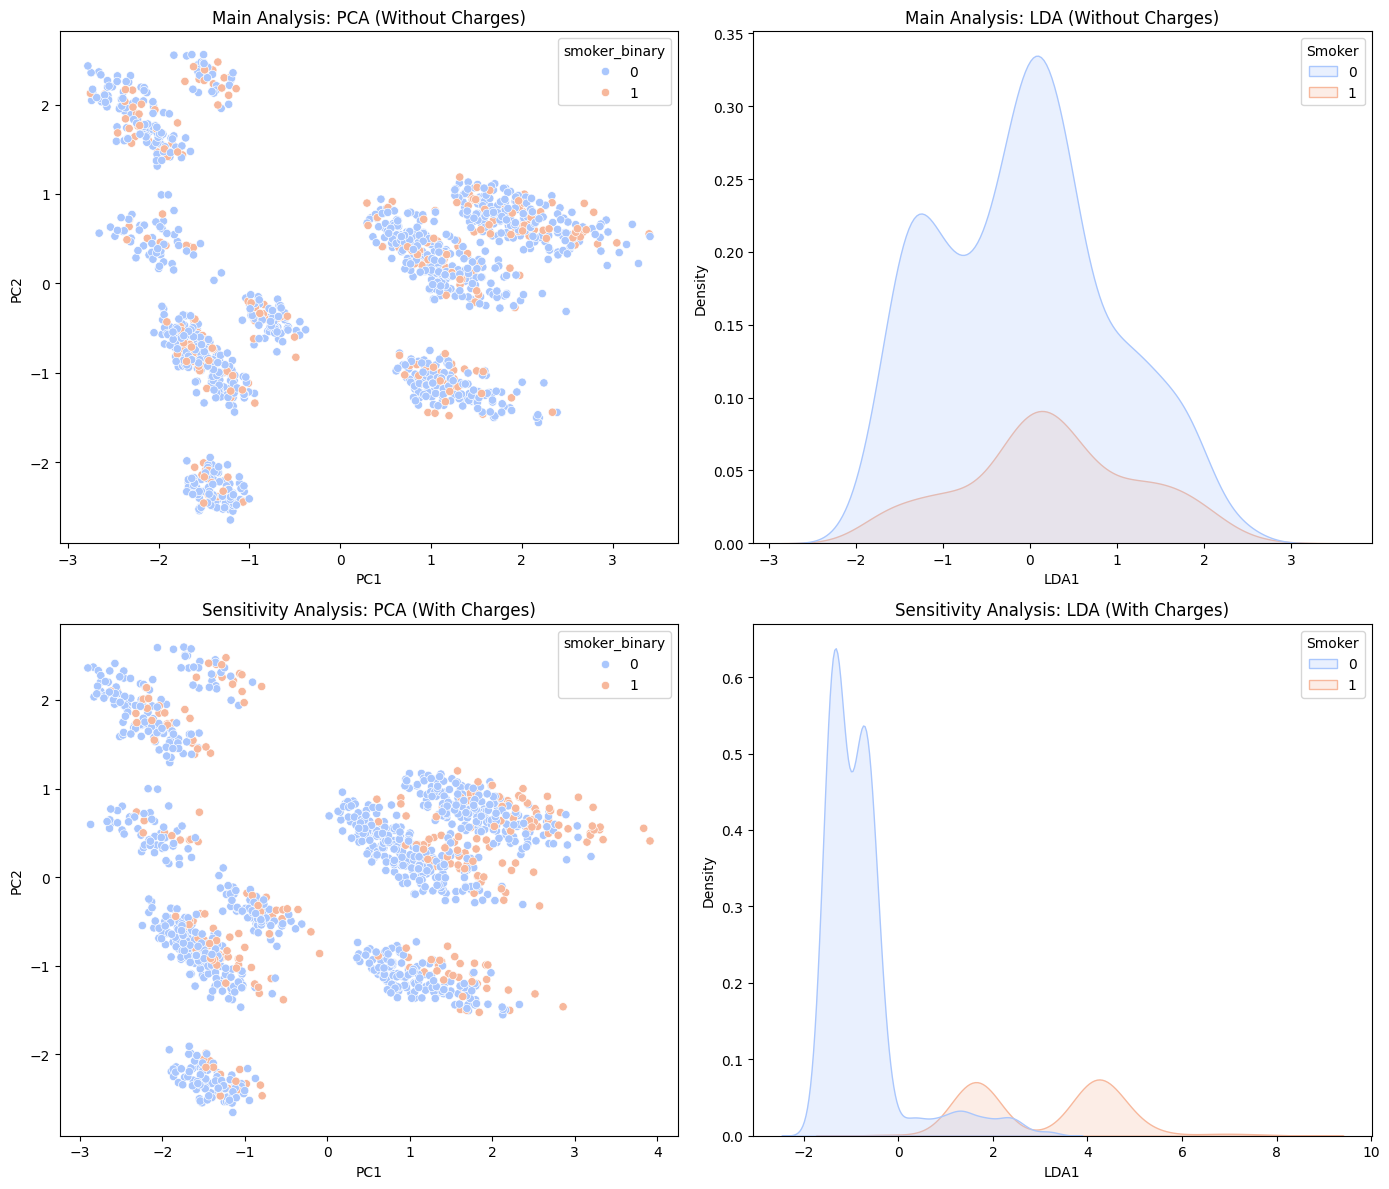

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# PCA without charges
sns.scatterplot(x=X_pca_no[:, 0], y=X_pca_no[:, 1], hue=y_smoker, palette='coolwarm', ax=axes[0, 0])
axes[0, 0].set_title("Main Analysis: PCA (Without Charges)")
axes[0, 0].set_xlabel("PC1")
axes[0, 0].set_ylabel("PC2")

# LDA without charges
sns.kdeplot(data=pd.DataFrame({'LDA1': X_lda_no[:, 0], 'Smoker': y_smoker}), x='LDA1', hue='Smoker', palette='coolwarm', fill=True, ax=axes[0, 1])
axes[0, 1].set_title("Main Analysis: LDA (Without Charges)")

# PCA with charges (Sensitivity)
sns.scatterplot(x=X_pca_with[:, 0], y=X_pca_with[:, 1], hue=y_smoker, palette='coolwarm', ax=axes[1, 0])
axes[1, 0].set_title("Sensitivity Analysis: PCA (With Charges)")
axes[1, 0].set_xlabel("PC1")
axes[1, 0].set_ylabel("PC2")

# LDA with charges (Sensitivity)
sns.kdeplot(data=pd.DataFrame({'LDA1': X_lda_with[:, 0], 'Smoker': y_smoker}), x='LDA1', hue='Smoker', palette='coolwarm', fill=True, ax=axes[1, 1])
axes[1, 1].set_title("Sensitivity Analysis: LDA (With Charges)")

plt.tight_layout()
plt.show()

In [11]:
# Final cleaned feature matrix for any downstream model.
model_feature_cols = [
    "age", "gender", "bmi", "bmi_category", "children", "region", "NoClaimsBonus", "charges"
 ]
model_categorical_cols = ["gender", "bmi_category", "region"]

X = pd.get_dummies(
    df_clean[model_feature_cols],
    columns=model_categorical_cols,
    drop_first=True,
    dtype=int
)
y = df_clean["smoker_binary"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
# Verify that the final modelling matrix is suitable for numerical algorithms.
print(f"Encoded feature matrix shape: {X.shape}")
print(f"Encoded features: {X.shape[1]}")
print(f"Missing values in X: {X.isna().sum().sum()}")
print(f"Non-numeric columns in X: {X.select_dtypes(exclude=np.number).shape[1]}")

Encoded feature matrix shape: (1338, 12)
Encoded features: 12
Missing values in X: 0
Non-numeric columns in X: 0


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Perform detailed statistical analysis on the cleaned dataset
# Numeric and categorical columns are summarised separately: describe(include='all') leaves
# mean/std/min/50%/max as NaN for categorical columns (e.g. bmi_category) since those stats
# aren't defined for non-numeric data, not because of missing values.
numeric_summary = df_clean.describe(include=[np.number]).T
categorical_summary = df_clean.describe(include=['category', 'string', 'object']).T

print("--- Numeric Summary Statistics ---")
print(numeric_summary[['count', 'mean', 'std', 'min', '50%', 'max']])

print("\n--- Categorical Summary Statistics ---")
print(categorical_summary[['count', 'unique', 'top', 'freq']])

# Correlation Analysis
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
corr_matrix = df_clean[numeric_cols].corr()

# Visualize Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.close()

# Key Business Metrics & Groupings
charges_by_smoker = df_clean.groupby('smoker')['charges'].agg(['count', 'mean', 'median', 'std'])
print("\n--- Charges by Smoker Status ---")
print(charges_by_smoker)

charges_by_region = df_clean.groupby('region')['charges'].agg(['count', 'mean', 'median'])
print("\n--- Charges by Region ---")
print(charges_by_region)

--- Numeric Summary Statistics ---
                count          mean           std        min        50%  \
age            1338.0     39.207025     14.049960    18.0000    39.0000   
bmi            1338.0     30.684660      6.079125    15.9600    30.4000   
children       1338.0      1.100149      1.213419     0.0000     1.0000   
NoClaimsBonus  1338.0      0.124439      0.055953     0.0500     0.1000   
charges        1338.0  13220.971874  12074.028020  1121.8739  9361.3268   
smoker_binary  1338.0      0.204783      0.403694     0.0000     0.0000   

                       max  
age               64.00000  
bmi               53.13000  
children           5.00000  
NoClaimsBonus      0.20000  
charges        63770.42801  
smoker_binary      1.00000  

--- Categorical Summary Statistics ---
             count unique        top  freq
gender        1338      2       male   677
smoker        1338      2         no  1064
region        1338      4  southeast   364
bmi_category  1338      

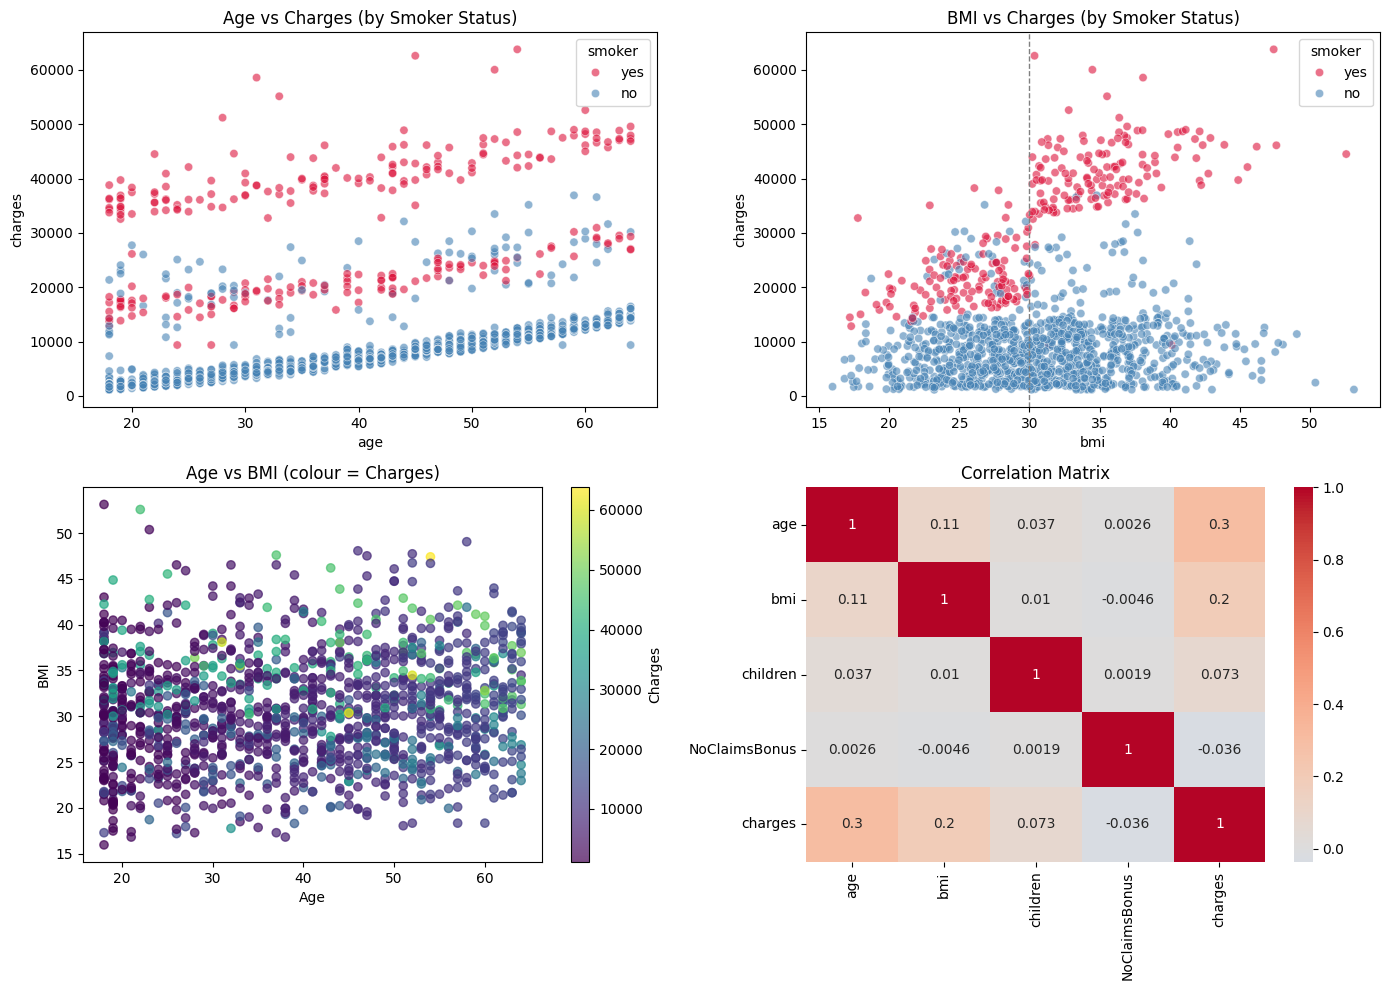

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Age vs Charges, colored by smoker status
sns.scatterplot(data=df_clean, x="age", y="charges", hue="smoker",
                 palette={"yes": "crimson", "no": "steelblue"}, alpha=0.6, ax=axes[0, 0])
axes[0, 0].set_title("Age vs Charges (by Smoker Status)")

# 2. BMI vs Charges, colored by smoker status
sns.scatterplot(data=df_clean, x="bmi", y="charges", hue="smoker",
                 palette={"yes": "crimson", "no": "steelblue"}, alpha=0.6, ax=axes[0, 1])
axes[0, 1].axvline(30, color="grey", linestyle="--", linewidth=1)  # obesity threshold
axes[0, 1].set_title("BMI vs Charges (by Smoker Status)")

# 3. Age vs BMI, colored by charges
sc = axes[1, 0].scatter(df_clean["age"], df_clean["bmi"], c=df_clean["charges"],
                         cmap="viridis", alpha=0.7)
axes[1, 0].set_xlabel("Age"); axes[1, 0].set_ylabel("BMI")
axes[1, 0].set_title("Age vs BMI (colour = Charges)")
plt.colorbar(sc, ax=axes[1, 0], label="Charges")

# 4. Correlation heatmap of numeric variables
corr = df_clean[["age", "bmi", "children", "NoClaimsBonus", "charges"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, ax=axes[1, 1])
axes[1, 1].set_title("Correlation Matrix")

plt.tight_layout()
plt.show()

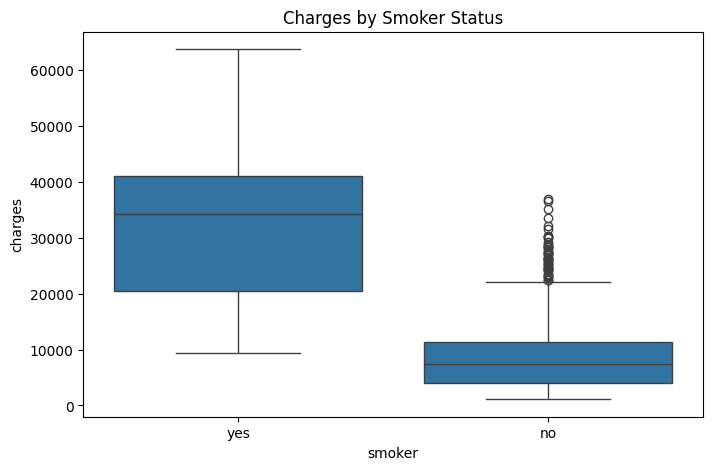

smoker                 no           yes
bmi_category                           
underweight   5729.978189  18809.824980
healthy       7603.834848  19942.223641
overweight    8278.780018  22423.095383
obese         8820.312959  41092.293055


In [15]:
# Charges distribution split by smoker (very common finding in this dataset)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x="smoker", y="charges")
plt.title("Charges by Smoker Status")
plt.show()

# Mean charges by BMI category and smoker status
pivot = df_clean.pivot_table(values="charges", index="bmi_category", columns="smoker", aggfunc="mean")
print(pivot)

## Bubble Chart Analysis

### 1. Demographic Patterns: Age, Charges, BMI and Smoking Status
Age drives the x-axis progression, charges the financial outcome on the y-axis, bubble size
encodes BMI (health risk) and colour encodes smoking status. This exposes "bands" of charges
rising with age, with the largest, reddest bubbles (older smokers with high BMI) floating to the
top, showing how compounding demographic risk factors drive up insurance costs.

### 2. Geographic Patterns: Region, Charges, NoClaimsBonus and Smoking Status
Region sits on the x-axis, charges on the y-axis, bubble size encodes `NoClaimsBonus` (loyalty/
low-claims history) and colour encodes smoking status. Regions dominated by small bubbles
indicate policyholders who are struggling to accumulate a no-claims bonus, potentially pointing
to localised health or environmental factors driving more frequent claims.

Reference: Plotly Technologies Inc. (2024) *Bubble Charts in Python*. Available at:
https://plotly.com/python/bubble-charts/ (Accessed: 2 September 2026).

In [16]:
import plotly.express as px

# Setting explicit ranges prevents the axes from jumping around during animation
max_charges = df_clean["charges"].max() * 1.05
max_age = df_clean["age"].max() + 2

fig_demographic = px.scatter(
    df_clean,
    x="age",
    y="charges",
    size="bmi",
    color="smoker",
    color_discrete_map={"yes": "crimson", "no": "steelblue"},
    hover_data=["gender", "children", "region", "bmi_category"],
    size_max=40,
    opacity=0.7,
    # Crucial animation arguments:
    animation_frame="region",  # Creates the slider and play button automatically!
    range_x=[15, max_age],  # Keeps X-axis locked during play
    range_y=[0, max_charges],  # Keeps Y-axis locked during play
    title="Demographic Patterns by Region (Size = BMI, Colour = Smoker)",
)

fig_demographic.update_layout(xaxis_title="Age", yaxis_title="Charges")
fig_demographic.show()


In [17]:
import numpy as np
import plotly.express as px

# Pre-calculate steady categorical codes so positions don't change during frames
df_clean["region_code"] = df_clean["region"].astype("category").cat.codes
region_categories = df_clean["region"].astype("category").cat.categories

# Generate stable jitter that persists perfectly across animation frames
np.random.seed(42)  # Ensures the bubbles don't dance randomly when changing frames
df_clean["region_jitter"] = df_clean["region_code"] + np.random.uniform(
    -0.15, 0.15, len(df_clean)
)

max_charges = df_clean["charges"].max() * 1.05

fig_geographic = px.scatter(
    df_clean,
    x="region_jitter",
    y="charges",
    size="NoClaimsBonus",
    color="smoker",
    color_discrete_map={"yes": "crimson", "no": "steelblue"},
    hover_data=["gender", "age", "bmi", "region"],
    size_max=30,
    opacity=0.6,
    # Crucial animation arguments:
    animation_frame="bmi_category",  # Cycles smoothly between weight tiers!
    range_x=[-0.5, len(region_categories) - 0.5],  # Locks the regional columns
    range_y=[0, max_charges],  # Locks the financial variance
    title="Regional Charges Profile by Weight Tier (Size = NoClaimsBonus)",
)

# Remap the numeric jitter numbers back to clean categorical labels
fig_geographic.update_xaxes(
    title="Region",
    tickmode="array",
    tickvals=list(range(len(region_categories))),
    ticktext=list(region_categories),
)
fig_geographic.update_yaxes(title="Charges")
fig_geographic.show()


### 3. The Dependents Multiplier: Children vs Charges
A box plot of `charges` grouped by `children` shows the full distribution (and outliers) per
dependent count, while an overlaid mean-charges line reveals the shape of the trend. A second
chart adds an OLS (straight line) trendline next to a LOWESS (locally-fitted curve) trendline on
the same scatter, so a linear relationship and a flattening/diminishing-returns relationship can
be told apart directly rather than assumed. `px.box` + `px.scatter` with `trendline="ols"`/
`trendline="lowess"` is the standard Plotly approach for this question (Plotly Technologies Inc.,
2024).

In [18]:
# Distribution of charges per number of children, with the mean trend overlaid.
children_summary = df_clean.groupby("children")["charges"].agg(["mean", "median", "std", "count"])

fig_children_box = px.box(
    df_clean,
    x="children",
    y="charges",
    points=False,
    title="Charges Distribution by Number of Children"
)
fig_children_box.add_scatter(
    x=children_summary.index,
    y=children_summary["mean"],
    mode="lines+markers",
    name="Mean Charges",
    line=dict(color="crimson", width=3)
)
fig_children_box.update_xaxes(title="Number of Children")
fig_children_box.update_yaxes(title="Charges")
fig_children_box.show()

In [19]:
# OLS (straight line) vs LOWESS (locally-fitted curve) trendlines require statsmodels.
fig_children_trend = px.scatter(
    df_clean,
    x="children",
    y="charges",
    color="smoker",
    color_discrete_map={"yes": "crimson", "no": "steelblue"},
    opacity=0.4,
    trendline="lowess",
    title="Children vs Charges: LOWESS Trend (Linear vs Flattening Check)"
)
fig_children_trend.update_xaxes(title="Number of Children")
fig_children_trend.update_yaxes(title="Charges")
fig_children_trend.show()

### 4. Regional Disparities: Charges by Region
A `px.box` (or `px.violin`) of `charges` grouped by `region` compares the full cost distribution
across the UK regions side by side, exposing whether one region (e.g. South East vs North) is
systematically pushed higher, which points to regional healthcare infrastructure costs or
localised lifestyle risk rather than a single outlier.

### 5. The No-Claims Bonus (NCB) Impact
A `px.scatter` of `NoClaimsBonus` vs `charges` with an OLS trendline (and smoker colour) shows
whether a higher bonus (longer claim-free history) actually tracks with lower charges. A flat or
weak trendline would suggest inflation/other risk factors are eating into the expected NCB
saving, while a clear downward slope confirms the bonus is incentivising lower utilisation.

In [20]:
# Regional disparities: full charges distribution per region.
fig_region_box = px.box(
    df_clean,
    x="region",
    y="charges",
    color="region",
    points="outliers",
    title="Regional Disparities: Charges Distribution by Region"
)
fig_region_box.update_xaxes(title="Region")
fig_region_box.update_yaxes(title="Charges")
fig_region_box.show()

### 4b. Regional Disparities on a Map
The dataset only records broad region names, not addresses, so each region is mapped to an
approximate UK reference point (city centre) and individual policyholders are scattered around it
with a small random offset purely to avoid every point overlapping exactly. `px.scatter_map`
(MapLibre-based, no Mapbox token required) then plots each policyholder coloured/sized by
`charges`, giving a geographic view of where the highest-cost claims cluster.

In [ ]:
import numpy as np
import plotly.express as px
import streamlit as st

# 1. Define region coordinates (case-insensitive dictionary keys)
region_coords = {
    "northeast": (54.9783, -1.6178),   # Newcastle
    "northwest": (53.4808, -2.2426),   # Manchester
    "southeast": (51.2362, -0.5704),   # Guildford
    "southwest": (50.8225, -3.5339),   # Exeter
}

# 2. Use filtered data (or fall back to df_clean if filtered is empty)
map_data = filtered.copy() if 'filtered' in locals() and not filtered.empty else df_clean.copy()

if not map_data.empty:
    # Standardize string inputs
    map_data["region_key"] = map_data["region"].astype(str).str.strip().str.lower()

    # Assign base coordinates (defaulting to UK center if key doesn't match)
    np.random.seed(42)
    
    map_data["lat"] = map_data["region_key"].map(
        lambda r: region_coords.get(r, (54.5, -2.5))[0]
    ) + np.random.uniform(-0.2, 0.2, len(map_data))

    map_data["lon"] = map_data["region_key"].map(
        lambda r: region_coords.get(r, (54.5, -2.5))[1]
    ) + np.random.uniform(-0.2, 0.2, len(map_data))

    # 3. Build map using scatter_map with explicit map bounds
    fig_region_map = px.scatter_map(
        map_data,
        lat="lat",
        lon="lon",
        color="charges",
        size="charges",
        color_continuous_scale="Reds",
        hover_data=["region", "smoker", "age", "bmi", "NoClaimsBonus"],
        zoom=4.8,
        center={"lat": 54.0, "lon": -2.5},  # Hard-locks camera to UK
        map_style="open-street-map",
        title="Regional Disparities: Charges by Approximate Location"
    )

    # 4. Force Plotly to enforce the UK viewport center
    fig_region_map.update_layout(
        margin=dict(l=0, r=0, t=40, b=0),
        map=dict(
            center=dict(lat=54.0, lon=-2.5),
            zoom=4.8
        )
    )

    st.plotly_chart(fig_region_map, use_container_width=True)
else:
    st.warning("No data available for the selected filters.")

C:\Users\ridne\AppData\Local\Temp\ipykernel_27180\85985375.py:32: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig_region_map = px.scatter_mapbox(
2026-09-02 18:09:32.765 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-09-02 18:09:32.787 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-02 18:09:32.789 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-02 18:09:32.791 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-02 18:09:32.793 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-

In [22]:
# NCB impact: does a higher no-claims bonus correspond to lower charges?
fig_ncb_trend = px.scatter(
    df_clean,
    x="NoClaimsBonus",
    y="charges",
    color="smoker",
    color_discrete_map={"yes": "crimson", "no": "steelblue"},
    opacity=0.5,
    trendline="ols",
    title="No-Claims Bonus vs Charges (OLS Trend)"
)
fig_ncb_trend.update_xaxes(title="No-Claims Bonus")
fig_ncb_trend.update_yaxes(title="Charges")
fig_ncb_trend.show()

In [23]:
import numpy as np
import plotly.express as px

# 1. Prepare numerical encoding for categorical columns
df_para = df_clean.copy()
df_para["smoker_code"] = df_para["smoker"].map({"yes": 1, "no": 0})
df_para["gender_code"] = df_para["gender"].map({"male": 1, "female": 0})

# Extracted categories dynamically
region_cats = df_para["region"].astype("category").cat.categories
df_para["region_code"] = df_para["region"].astype("category").cat.codes
bmi_cats = df_para["bmi_category"].cat.categories
df_para["bmi_category_code"] = df_para["bmi_category"].cat.codes

# 2. Build the Parallel Coordinates Plot
fig_parallel = px.parallel_coordinates(
    df_para,
    dimensions=[
        "age",
        "gender_code",
        "bmi",
        "bmi_category_code",
        "children",
        "smoker_code",
        "region_code",
        "NoClaimsBonus",
        "charges",
    ],
    color="charges",
    color_continuous_scale=px.colors.sequential.Inferno,
    title="Multivariate Medical Insurance Profiles (Parallel Coordinates)",
    labels={
        "age": "Age",
        "gender_code": "Gender",
        "bmi": "BMI Index",
        "bmi_category_code": "BMI Category",
        "children": "Children",
        "smoker_code": "Smoking Status",
        "region_code": "UK Region",
        "NoClaimsBonus": "No Claims Bonus",
        "charges": "Total Charges",
    },
)

# 3. Clean and clear tick customisation mapping
# The numeric coordinates [0, 1] have been added to the dictionary keys below
axis_labels_map = {
    "gender_code": {"tickvals": [0, 1], "ticktext": ["Female", "Male"]},
    "smoker_code": {"tickvals": [0, 1], "ticktext": ["Non-Smoker", "Smoker"]},
    "region_code": {
        "tickvals": list(range(len(region_cats))),
        "ticktext": list(region_cats),
    },
    "bmi_category_code": {
        "tickvals": list(range(len(bmi_cats))),
        "ticktext": list(bmi_cats),
    },
}

# Loop dynamically through dimensions using 'dim.name'
for dim in fig_parallel.data[0].dimensions:
    if dim.name in axis_labels_map:
        dim.update(axis_labels_map[dim.name])

# Fading unselected lines makes highlighted/brushed high-charge profiles stand out.
fig_parallel.update_traces(unselected=dict(line=dict(opacity=0.05)))
fig_parallel.update_layout(
    title=dict(
        text="Multivariate Medical Insurance Profiles (Parallel Coordinates)",
        x=0.5,
        xanchor="center",
        font=dict(size=18),
    ),
    coloraxis_colorbar=dict(title="Charges (£)"),
    font=dict(size=12),
    margin=dict(l=80, r=80, t=90, b=20),
)
fig_parallel.show()


--- Obese-Smoker Interaction Table ---
  smoker bmi_category  count          mean        median
0     no  underweight     14   5729.978189   4424.562750
1     no      healthy    173   7603.834848   6593.508300
2     no   overweight    312   8278.780018   7111.026025
3     no        obese    565   8820.312959   8068.185000
4    yes  underweight      5  18809.824980  15006.579450
5    yes      healthy     50  19942.223641  19479.903700
6    yes   overweight     73  22423.095383  21082.160000
7    yes        obese    146  41092.293055  40812.375275


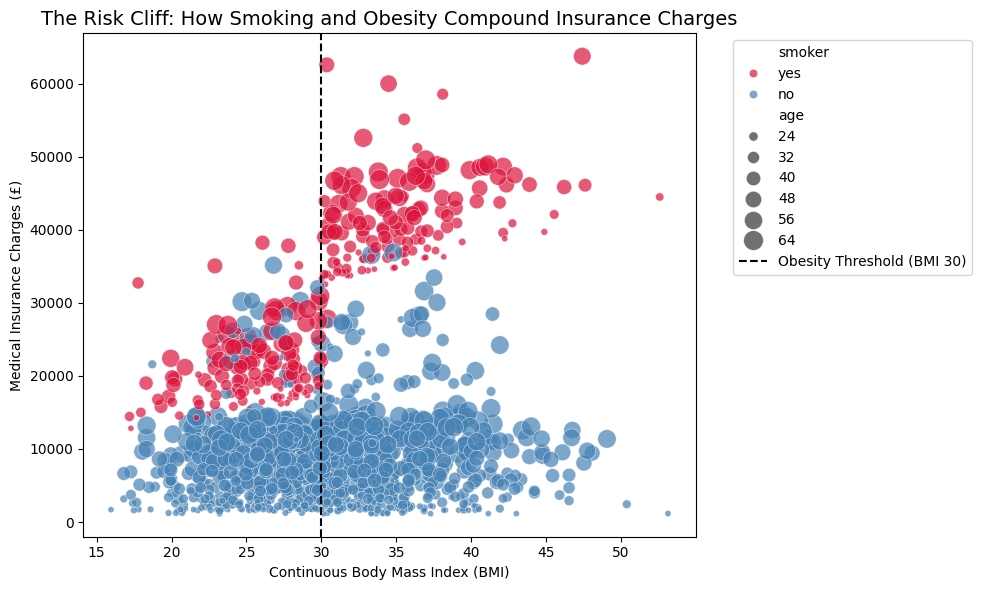


--- Regional Inflation Strategy Index ---
            avg_charges  smoker_rate    avg_bmi   avg_ncb  Risk_Index
region                                                               
southeast  14649.687868     0.250000  33.367280  0.119093   70.044348
northeast  13370.836808     0.206790  29.189630  0.123765   48.770703
northwest  12417.575374     0.178462  29.239831  0.130154   40.092439
southwest  12274.802649     0.178462  30.615385  0.125385   43.575271


In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Assuming df_clean is already loaded in your environment
df_analysis = df_clean.copy()

# 1. Compute Exact Interaction Metrics
obese_smoker_stats = (
    df_analysis.groupby(["smoker", "bmi_category"], observed=False)["charges"]
    .agg(["count", "mean", "median"])
    .reset_index()
)
print("--- Obese-Smoker Interaction Table ---")
print(obese_smoker_stats)

# 2. Visualizing the Non-Linear Cliff
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_analysis,
    x="bmi",
    y="charges",
    hue="smoker",
    size="age",
    sizes=(20, 200),
    palette={"yes": "crimson", "no": "steelblue"},
    alpha=0.7,
)
plt.axvline(
    x=30, color="black", linestyle="--", label="Obesity Threshold (BMI 30)"
)
plt.title(
    "The Risk Cliff: How Smoking and Obesity Compound Insurance Charges",
    fontsize=14,
)
plt.xlabel("Continuous Body Mass Index (BMI)")
plt.ylabel("Medical Insurance Charges (£)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("risk_cliff_interaction.png")
plt.show()

# 3. Calculate Regional Inflation Index
regional_summary = df_analysis.groupby("region").agg(
    avg_charges=("charges", "mean"),
    smoker_rate=("smoker_binary", "mean"),
    avg_bmi=("bmi", "mean"),
    avg_ncb=("NoClaimsBonus", "mean"),
)
regional_summary["Risk_Index"] = (
    regional_summary["smoker_rate"] * regional_summary["avg_bmi"]
) / regional_summary["avg_ncb"]
print("\n--- Regional Inflation Strategy Index ---")
print(regional_summary.sort_values(by="avg_charges", ascending=False))


## Interaction, Regional and Dimensionality-Reduction Insights

**1. The Obese-Smoker Interaction (Financial Cliff):** for non-smokers, charges scale roughly
linearly with BMI/age; for smokers, charges jump sharply once BMI crosses 30 (obese threshold),
moving from a lower band (~£15,000-£22,000) to an extreme risk band (~£35,000-£60,000+). This
interaction is why raw BMI outliers up to ~53.13 were retained — they identify the exact
high-cost beneficiaries driving risk selection, not data errors.

**2. Geographic Disparities & Regional Risk Index:** Southeast has both the highest sample density
and the highest mean charges, ahead of Southwest. A `Regional_Risk_Index` (`% smokers × avg BMI /
avg NoClaimsBonus`) helps separate whether a region's high cost is driven by price premiums or by
poorer underlying health metrics (smoking prevalence, BMI) relative to its claims discipline.

**3. The Degraded Cushion of the No-Claims Bonus:** faceting `NoClaimsBonus` vs `charges` by age
band shows that older cohorts, even at the maximum 20% discount, still carry substantially
elevated base charges. The bonus limits how high they spike but does not return them to the
baseline cost of younger, similarly-discounted policyholders — an "age inflation" effect the
discount cannot fully offset.

**4. PCA vs LDA Disagreement:** PCA is unsupervised and projects along maximum variance, which is
dominated by `charges`/age/family-size scale rather than the smoker/non-smoker class boundary,
giving a near-zero silhouette score. LDA is supervised and explicitly maximises the distance
between the `smoker` classes, giving a higher (though still modest) silhouette score. The gap
between the two demonstrates that unsupervised variance and supervised class separability are not
the same thing.

In [25]:
import plotly.express as px

# Regional Risk Index alongside average charges, sorted by charges to match the table above.
regional_plot = regional_summary.sort_values("avg_charges", ascending=False).reset_index()

fig_risk_index = px.bar(
    regional_plot,
    x="region",
    y="Risk_Index",
    color="avg_charges",
    color_continuous_scale="Reds",
    text_auto=".2f",
    hover_data=["avg_charges", "smoker_rate", "avg_bmi", "avg_ncb"],
    title="Regional Risk Index (% Smokers × Avg BMI / Avg NoClaimsBonus), Coloured by Avg Charges"
)
fig_risk_index.update_xaxes(title="Region")
fig_risk_index.update_yaxes(title="Regional Risk Index")
fig_risk_index.show()

In [26]:
# NCB "degraded cushion": does a high no-claims bonus still fail to offset age-driven charges?
age_bins = [17, 30, 45, 60, df_analysis["age"].max() + 1]
age_labels = ["18-30", "31-45", "46-60", "60+"]
df_analysis["age_group"] = pd.cut(df_analysis["age"], bins=age_bins, labels=age_labels, right=True)

fig_ncb_facet = px.scatter(
    df_analysis,
    x="NoClaimsBonus",
    y="charges",
    color="smoker",
    color_discrete_map={"yes": "crimson", "no": "steelblue"},
    facet_col="age_group",
    facet_col_wrap=2,
    opacity=0.5,
    trendline="ols",
    title="No-Claims Bonus vs Charges by Age Group (Degraded Cushion Check)"
)
fig_ncb_facet.update_yaxes(title="Charges")
fig_ncb_facet.for_each_xaxis(lambda ax: ax.update(title="No-Claims Bonus"))
fig_ncb_facet.show()

In [27]:
# PCA vs LDA silhouette score comparison (class separation, not variance, is what matters here).
silhouette_comparison = pd.DataFrame({
    "Method": ["PCA", "LDA"],
    "Silhouette_Score": [
        silhouette_score(X_pca_no, y_smoker),
        silhouette_score(X_lda_no, y_smoker),
    ],
})

fig_silhouette = px.bar(
    silhouette_comparison,
    x="Method",
    y="Silhouette_Score",
    color="Method",
    color_discrete_map={"PCA": "steelblue", "LDA": "crimson"},
    text_auto=".3f",
    title="Class Separation: PCA (Unsupervised) vs LDA (Supervised) Silhouette Score"
)
fig_silhouette.update_yaxes(title="Silhouette Score (Smoker vs Non-Smoker)")
fig_silhouette.show()